# HI-VIS — Automated PPE Compliance Detection

**Le Wagon Data Science & AI · Batch #2303 · Final Project**

Point a model at a construction-site photograph and get back who is in it, what PPE they're wearing, and what's missing — turning site photos every project already takes into a checked, dated, searchable safety record.

This notebook is the shared starting point: data loading, EDA, a CNN baseline, and a YOLO object-detection model.


## 1 · Setup

In [1]:
# Core
import os
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# Modelling (transfer learning baseline)
# import tensorflow as tf
# from tensorflow.keras import layers, Sequential
# from tensorflow.keras.applications.vgg16 import VGG16

# Object detection
# from ultralytics import YOLO   # pip install ultralytics

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


## 2 · Data

**Primary dataset:** [Construction Site Safety Image Dataset (Roboflow export)](https://www.kaggle.com/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow) — 2,801 images, YOLOv8 format, CC BY 4.0.

Classes (10): `Hardhat`, `Mask`, `NO-Hardhat`, `NO-Mask`, `NO-Safety Vest`, `Person`, `Safety Cone`, `Safety Vest`, `machinery`, `vehicle`.

Reference notebook using this same dataset: [PPE Kit Detection — Construction Site Safety](https://www.kaggle.com/code/sajjadalishah/ppe-kit-detection-construction-site-safety).



### ⚠️ If you downloaded the reference notebook's "Output" from Kaggle

Kaggle lets you download a public notebook's entire output bundle, not just the input dataset — put in all in `data/`, it unpacks into **three unrelated things**, not one clean dataset:

```
data/
├── css-data/                          ← the ACTUAL dataset — use this as DATA_DIR
│   ├── README.dataset.txt / README.roboflow.txt
│   ├── train/{images,labels}/
│   ├── valid/{images,labels}/
│   └── test/{images,labels}/
├── results_yolov8n_100e/              ← the reference notebook's OWN completed training run
│   └── kaggle/working/
│       ├── __notebook__.ipynb         ← the reference notebook's actual source + outputs
│       ├── yolov8n.pt                 ← base COCO checkpoint (untouched)
│       ├── ppe_data.yaml              ← the data.yaml that run was trained with
│       └── runs/detect/train/weights/
│           ├── best.pt                ← already fine-tuned on THIS dataset (100 epochs)
│           └── last.pt
└── source_files/source_files/         ← random demo images/videos, not training data
```


In [2]:
DATA_DIR = Path("data/css-data")

for split in ["train", "valid", "test"]:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    n_img = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    n_lbl = len(list(lbl_dir.glob("*"))) if lbl_dir.exists() else 0
    print(f"{split:6s} images={n_img:5d}  labels={n_lbl:5d}")


train  images= 2605  labels= 2605
valid  images=  114  labels=  114
test   images=   82  labels=   82


In [3]:
# The Roboflow export doesn't always ship its own data.yaml (ours didn't) — write one.
# Class order below matches ppe_data.yaml from the reference notebook's run, so it's
# consistent with results_yolov8n_100e's weights too.
import yaml


# TODO: fix the path to point it at your downloaded data folder

CLASS_NAMES = [
    "Hardhat", "Mask", "NO-Hardhat", "NO-Mask", "NO-Safety Vest",
    "Person", "Safety Cone", "Safety Vest", "machinery", "vehicle",
]

data_cfg = {
    "train": str((DATA_DIR / "train" / "images").resolve()),
    "val": str((DATA_DIR / "valid" / "images").resolve()),
    "test": str((DATA_DIR / "test" / "images").resolve()),
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES,
}

yaml_path = DATA_DIR / "data.yaml"
with open(yaml_path, "w") as f:
    yaml.safe_dump(data_cfg, f)

print(f"wrote {yaml_path}")
print(data_cfg)


wrote data/css-data/data.yaml
{'train': '/Users/joanna/code/ds-final-project/P0-safety/data/css-data/train/images', 'val': '/Users/joanna/code/ds-final-project/P0-safety/data/css-data/valid/images', 'test': '/Users/joanna/code/ds-final-project/P0-safety/data/css-data/test/images', 'nc': 10, 'names': ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']}


### Quick sanity check — try the reference checkpoint before training anything

`results_yolov8n_100e` contains a YOLOv8n **already fine-tuned on this exact dataset** (100 epochs, on a Kaggle P100, per the reference notebook). Before spending GPU time on your own run, load it and confirm it actually detects PPE.


In [4]:
from ultralytics import YOLO

REFERENCE_WEIGHTS = DATA_DIR.parent / "results_yolov8n_100e" / "kaggle" / "working" / "runs" / "detect" / "train" / "weights" / "best.pt"

reference_model = YOLO(str(REFERENCE_WEIGHTS))
sample_image = random.choice(list((DATA_DIR / "test" / "images").glob("*")))
results = reference_model(str(sample_image))
results[0].show()   # or results[0].save("sanity_check.jpg")


FileNotFoundError: [Errno 2] No such file or directory: 'data/results_yolov8n_100e/kaggle/working/runs/detect/train/weights/best.pt'

## 3 · Exploratory Data Analysis

Same instinct as `Module 22`: look at the structure of the data *before* trusting any model output. For a detection dataset that means, at minimum:

1. **Class balance** — per the pitch's own risk register, `NO-Hardhat` / `NO-Mask` / `NO-Safety Vest` are expected to be far rarer than their positive counterparts. Confirm it, don't assume it.
2. **Image properties** — resolution, aspect ratio, lighting variety (site photos won't be as clean as ImageNet).
3. **Box size distribution** — small/occluded objects (a bare head at a distance) are called out in the pitch as the hardest case; know how many of those you actually have.
4. **Visual sanity check** — draw the YOLO-format label boxes on a handful of images to catch annotation issues early.


In [5]:
def parse_yolo_labels(label_path, class_names):
    """Read a YOLO-format .txt label file into a list of (class_name, x, y, w, h) — all normalised 0-1."""
    rows = []
    if not Path(label_path).exists():
        return rows
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            cls_id, x, y, w, h = int(parts[0]), *map(float, parts[1:5])
            rows.append((class_names[cls_id], x, y, w, h))
    return rows


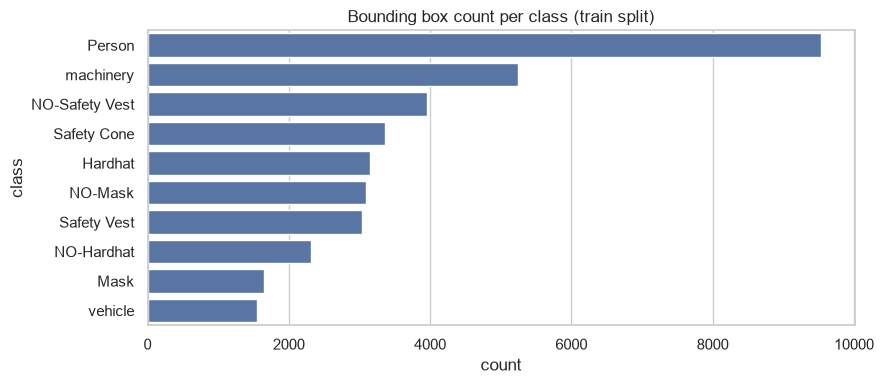

In [6]:
# Class distribution across the training split
records = []
train_labels_dir = DATA_DIR / "train" / "labels"
if train_labels_dir.exists():
    for lbl_file in train_labels_dir.glob("*.txt"):
        for cls_name, x, y, w, h in parse_yolo_labels(lbl_file, CLASS_NAMES):
            records.append({"class": cls_name, "w": w, "h": h, "area": w * h})

df_labels = pd.DataFrame(records)

if not df_labels.empty:
    plt.figure(figsize=(9, 4))
    order = df_labels["class"].value_counts().index
    sns.countplot(data=df_labels, y="class", order=order)
    plt.title("Bounding box count per class (train split)")
    plt.xlabel("count")
    plt.tight_layout()
    plt.show()
else:
    print("No labels parsed yet — download the dataset first.")


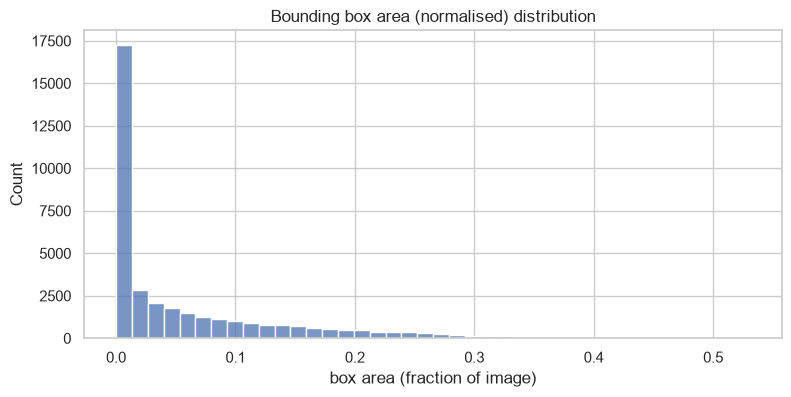

class
Safety Cone       0.000428
NO-Mask           0.001235
Hardhat           0.001934
vehicle           0.006460
NO-Hardhat        0.007471
Safety Vest       0.009399
NO-Safety Vest    0.028204
Mask              0.051299
Person            0.061985
machinery         0.119629
Name: area, dtype: float64


In [7]:
# Box-area distribution (proxy for "how many small/occluded objects are we dealing with?")
if not df_labels.empty:
    plt.figure(figsize=(9, 4))
    sns.histplot(df_labels["area"], bins=40)
    plt.title("Bounding box area (normalised) distribution")
    plt.xlabel("box area (fraction of image)")
    plt.show()

    print(df_labels.groupby("class")["area"].median().sort_values())


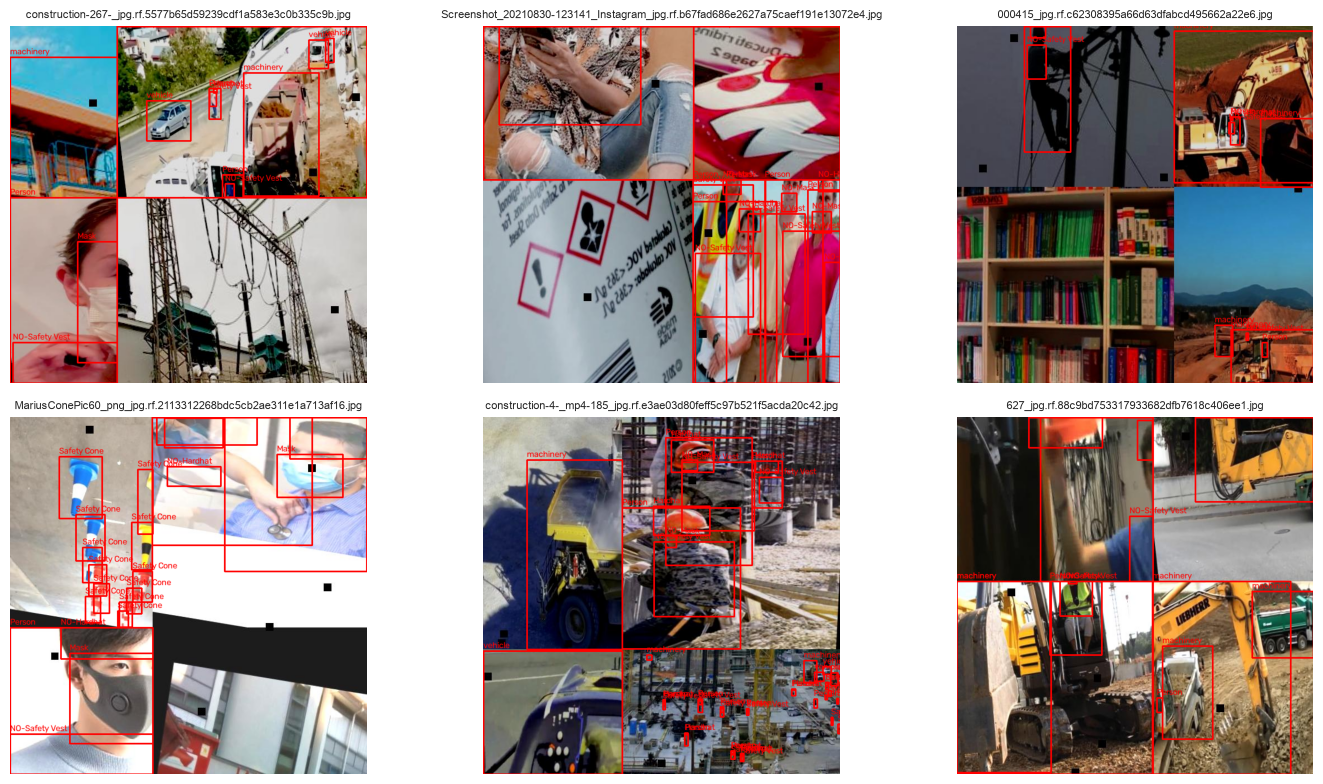

In [8]:
def draw_boxes(image_path, label_path, class_names):
    img = cv2.imread(str(image_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h_img, w_img = img.shape[:2]

    for cls_name, x, y, w, h in parse_yolo_labels(label_path, class_names):
        x1, y1 = int((x - w / 2) * w_img), int((y - h / 2) * h_img)
        x2, y2 = int((x + w / 2) * w_img), int((y + h / 2) * h_img)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img, cls_name, (x1, max(y1 - 5, 0)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    return img


# Sanity-check a handful of random training images with their labels overlaid
train_images_dir = DATA_DIR / "train" / "images"
if train_images_dir.exists():
    sample_images = random.sample(list(train_images_dir.glob("*")), k=min(6, len(list(train_images_dir.glob("*")))))
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    for ax, img_path in zip(axes.flat, sample_images):
        lbl_path = train_labels_dir / (img_path.stem + ".txt")
        ax.imshow(draw_boxes(img_path, lbl_path, CLASS_NAMES))
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


### Comparing to the other two candidate datasets

how big is each one, how are their classes distributed


In [9]:
# Neither of these ships in exactly the same shape as css-data, so a small config block
# up front beats hard-coding paths three times over. Class lists below are NOT guesses —
# PPE Kit Detection has no data.yaml in the Kaggle download, so its class order was
# confirmed against Ultralytics' docs page for this same dataset (their split sizes —
# 1132/143/141 — match ours exactly, so it's the same release).
OTHER_DATASETS = {
    "PPE Kit Detection": {
        "dir": DATA_DIR.parent / "PPE Kit Detection",
        "layout": "type_first",  # <dir>/images/<split>/, <dir>/labels/<split>/
        "splits": {"train": "train", "valid": "val", "test": "test"},  # note: "val", not "valid"
        "classes": [
            "helmet", "gloves", "vest", "boots", "goggles", "none",
            "Person", "no_helmet", "no_goggle", "no_gloves", "no_boots",
        ],
    },
    "ppe_detection_m": {
        "dir": DATA_DIR.parent / "ppe_detection_m",
        "layout": "split_first",  # <dir>/<split>/images/, <dir>/<split>/labels/ — same as css-data
        "splits": {"train": "train", "valid": "valid", "test": "test"},
        "classes": [
            "no-safety-glove", "no-safety-helmet", "no-safety-shoes", "no-welding-glass",
            "safety-glove", "safety-helmet", "safety-shoes", "welding-glass",
        ],
        # This one does ship its own dataset.yaml with a pre-computed "class_distribution"
        # block, and it checks out — recomputing from the .txt label files below matches it
        # exactly. Still parsed from the raw files rather than trusted at face value, same
        # habit as the rest of this section (worth doing even when it turns out fine).
    },
}


def resolve_split_dirs(data_dir, split_folder, layout):
    if layout == "split_first":
        return data_dir / split_folder / "images", data_dir / split_folder / "labels"
    return data_dir / "images" / split_folder, data_dir / "labels" / split_folder


def load_dataset(name, data_dir, splits, layout, class_names):
    """Reuses parse_yolo_labels (Section 3) across every split of one dataset, tagging
    each row with the dataset name so results from all three can live in one DataFrame."""
    records, n_images = [], {}
    for split_label, folder_name in splits.items():
        images_dir, labels_dir = resolve_split_dirs(data_dir, folder_name, layout)
        n_images[split_label] = len(list(images_dir.glob("*"))) if images_dir.exists() else 0
        if not labels_dir.exists():
            continue
        for lbl_file in labels_dir.glob("*.txt"):
            for cls_name, x, y, w, h in parse_yolo_labels(lbl_file, class_names):
                records.append({"dataset": name, "class": cls_name, "w": w, "h": h, "area": w * h})
    return records, n_images


# css-data itself, in the same shape, so it can sit in the same comparison table/plots.
all_records, image_counts = [], {}
recs, imgs = load_dataset("css-data", DATA_DIR, {"train": "train", "valid": "valid", "test": "test"}, "split_first", CLASS_NAMES)
all_records += recs
image_counts["css-data"] = imgs

for name, cfg in OTHER_DATASETS.items():
    recs, imgs = load_dataset(name, cfg["dir"], cfg["splits"], cfg["layout"], cfg["classes"])
    all_records += recs
    image_counts[name] = imgs

df_compare = pd.DataFrame(all_records)
print(f"{len(df_compare):,} total bounding boxes loaded across all three datasets.")


101,698 total bounding boxes loaded across all three datasets.


In [10]:
# Summary table: scale + class balance, side by side. Imbalance ratio = largest class's
# instance count / smallest class's — a rough single-number stand-in for "how skewed is this."
summary_rows = []
for name, imgs in image_counts.items():
    class_counts = df_compare.loc[df_compare["dataset"] == name, "class"].value_counts()
    summary_rows.append({
        "dataset": name,
        "images (train/valid/test)": f"{imgs.get('train', 0)}/{imgs.get('valid', 0)}/{imgs.get('test', 0)}",
        "total images": sum(imgs.values()),
        "num classes": class_counts.shape[0],
        "total instances": int(class_counts.sum()),
        "largest class": f"{class_counts.idxmax()} ({class_counts.max()})",
        "smallest class": f"{class_counts.idxmin()} ({class_counts.min()})",
        "imbalance ratio (max/min)": round(class_counts.max() / class_counts.min(), 1),
    })

df_summary = pd.DataFrame(summary_rows).set_index("dataset")
df_summary


,images (train/valid/test),total images,num classes,total instances,largest class,smallest class,imbalance ratio (max/min)
dataset,,,,,,,
css-data,2605/114/82,2801,10,38352,Person (9872),vehicle (1628),6.1
PPE Kit Detection,1132/143/141,1416,11,11614,Person (2265),no_boots (115),19.7
ppe_detection_m,8691/4201/2276,15168,8,51732,safety-shoes (9342),no-welding-glass (4094),2.3


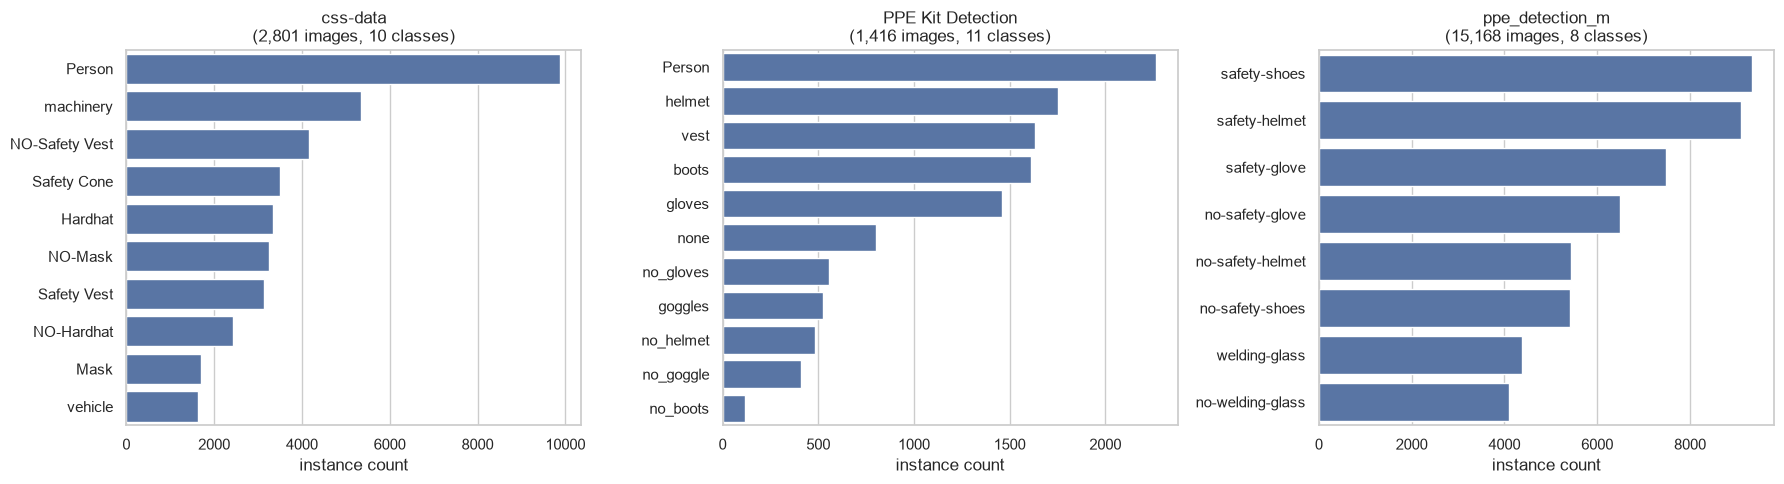

In [11]:
# Per-class instance counts, one panel per dataset — same countplot style as the
# single-dataset version above, just faceted so the three are easy to eyeball together.
dataset_names = list(image_counts.keys())
fig, axes = plt.subplots(1, len(dataset_names), figsize=(6 * len(dataset_names), 5))
for ax, name in zip(axes, dataset_names):
    subset = df_compare[df_compare["dataset"] == name]
    order = subset["class"].value_counts().index
    sns.countplot(data=subset, y="class", order=order, ax=ax)
    ax.set_title(f"{name}\n({sum(image_counts[name].values()):,} images, {subset['class'].nunique()} classes)")
    ax.set_xlabel("instance count")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


**What this says about picking a dataset:**

- **Class taxonomies don't line up 1:1.** Only `Hardhat`/`helmet` is common to all three, under different names. `css-data` is the only one with `Mask` and a `Vest` class — both are in the pitch's own risk register — and it's also the only one that goes beyond PPE items at all (`Person`, `Safety Cone`, `machinery`, `vehicle`). `PPE Kit Detection` is the only one with `boots` and `goggles`. `ppe_detection_m` has no generic `Person`/background class at all, only PPE-item boxes, and its "welding glass" is a narrower concept than general eye protection. Concretely: none of these can just be pooled into one `data.yaml` without relabeling — a class merge would need a manual name-mapping table first.
- **`ppe_detection_m` is by far the biggest** (15k+ images, ~5–10× the others) but the narrowest in scope — worth considering as a way to pretrain/pad out glove, helmet and shoe detection specifically, not as a drop-in replacement for `css-data`.
- **`PPE Kit Detection` is the smallest** (1,416 images) and, per the imbalance ratio above, by a wide margin the most skewed of the three — its rarest violation classes (`no_boots`, `no_goggle`) have only a few hundred instances total. That's the same "far rarer than its positive counterpart" pattern the pitch already calls out for `NO-Hardhat` etc. in `css-data`, just worse here.
- **Bottom line for now:** `css-data` still matches the pitch's own class list most closely, so it stays the primary training set. The other two are better thought of as potential *supplements* for specific gaps (boots/goggles from `PPE Kit Detection`, more raw glove/helmet/shoe volume from `ppe_detection_m`) than as alternatives to switch to outright — worth a team discussion before committing training time to either.


## 4 · Basic CNN

Use transfer learning and build a basic classifier to establish a floor.
We test with ImageNet which is a huge public dataset (about 1.4 million photos across 1,000 everyday categories (dogs, cars, chairs, bottles, and so on)). 

The hardhat/no-hardhat distinction comes from the dataset's labels  (the YOLO `.txt`).

1) read each label file, 
2) keep only the `Hardhat` / `NO-Hardhat` boxes
3) crop just that region out of the source image (in case there are multiple boxes in a photo that matters for training)
4) save each crop into `data/baseline_crops/hardhat/` or `data/baseline_crops/no_hardhat/`. 

`tf.keras.utils.image_dataset_from_directory` infers the label for every image purely from which of those two folders it's sitting in.


In [12]:
def crop_head_regions(images_dir, labels_dir, class_names, output_dir, padding=0.1):
    """Crop the Hardhat / NO-Hardhat boxes out of each image and sort the crops into
    output_dir/hardhat/ and output_dir/no_hardhat/ — the folder split
    image_dataset_from_directory (next cell) uses to infer labels automatically."""
    output_dir = Path(output_dir)
    (output_dir / "hardhat").mkdir(parents=True, exist_ok=True)
    (output_dir / "no_hardhat").mkdir(parents=True, exist_ok=True)
    n_saved = {"hardhat": 0, "no_hardhat": 0}

    for label_path in Path(labels_dir).glob("*.txt"):
        image_path = Path(images_dir) / (label_path.stem + ".jpg")
        if not image_path.exists():
            continue
        img = cv2.imread(str(image_path))
        if img is None:
            continue
        h_img, w_img = img.shape[:2]

        for i, (cls_name, x, y, w, h) in enumerate(parse_yolo_labels(label_path, class_names)):
            if cls_name not in ("Hardhat", "NO-Hardhat"):
                continue

            # normalized YOLO box -> pixel box, with a little padding around the head
            bw, bh = w * (1 + padding), h * (1 + padding)
            x1 = max(int((x - bw / 2) * w_img), 0)
            y1 = max(int((y - bh / 2) * h_img), 0)
            x2 = min(int((x + bw / 2) * w_img), w_img)
            y2 = min(int((y + bh / 2) * h_img), h_img)

            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue

            folder = "hardhat" if cls_name == "Hardhat" else "no_hardhat"
            cv2.imwrite(str(output_dir / folder / f"{label_path.stem}_{i}.jpg"), crop)
            n_saved[folder] += 1

    return n_saved


crop_counts = crop_head_regions(
    images_dir=DATA_DIR / "train" / "images",
    labels_dir=DATA_DIR / "train" / "labels",
    class_names=CLASS_NAMES,
    output_dir=DATA_DIR / "baseline_crops",
)
print(crop_counts)

{'hardhat': 3145, 'no_hardhat': 2317}


In [13]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "baseline_crops",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",     # single 0/1 label — matches the sigmoid output below
    validation_split=0.2,
    subset="training",
    seed=RANDOM_STATE,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR / "baseline_crops",
    image_size=(224, 224),
    batch_size=32,
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=RANDOM_STATE,
)

print(train_ds.class_names)  # expect: ['hardhat', 'no_hardhat'] -> hardhat=0, no_hardhat=1


Found 5462 files belonging to 2 classes.
Using 4370 files for training.
Found 5462 files belonging to 2 classes.
Using 1092 files for validation.
['hardhat', 'no_hardhat']


In [14]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import layers, Sequential

base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze the convolutional base, same as the bootcamp challenge

baseline_model = Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),  # hardhat vs no-hardhat
])
baseline_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping],
)

Epoch 1/30


/Users/joanna/.pyenv/versions/3.12.9/envs/hivis-ppe/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


137/137 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.8224 - loss: 0.5934 - val_accuracy: 0.8791 - val_loss: 0.2884
Epoch 2/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.8959 - loss: 0.2384 - val_accuracy: 0.8984 - val_loss: 0.2683
Epoch 3/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9405 - loss: 0.1377 - val_accuracy: 0.9020 - val_loss: 0.2494
Epoch 4/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 248s 2s/step - accuracy: 0.9572 - loss: 0.0983 - val_accuracy: 0.8810 - val_loss: 0.3575
Epoch 5/30
137/137 ━━━━━━━━━━━━━━━━━━━━ 245s 2s/step - accuracy: 0.9670 - loss: 0.0778 - val_accuracy: 0.9038 - val_loss: 0.3257
Epoch 6/30
 51/137 ━━━━━━━━━━━━━━━━━━━━ 2:05 1s/step - accuracy: 0.9755 - loss: 0.0640

KeyboardInterrupt: 

In [ ]:
loss, accuracy = baseline_model.evaluate(val_ds)
print(f"val loss: {loss:.3f}, val accuracy: {accuracy:.3f}")

35/35 ━━━━━━━━━━━━━━━━━━━━ 9s 250ms/step - accuracy: 0.8645 - loss: 1.3151
val loss: 1.315, val accuracy: 0.864


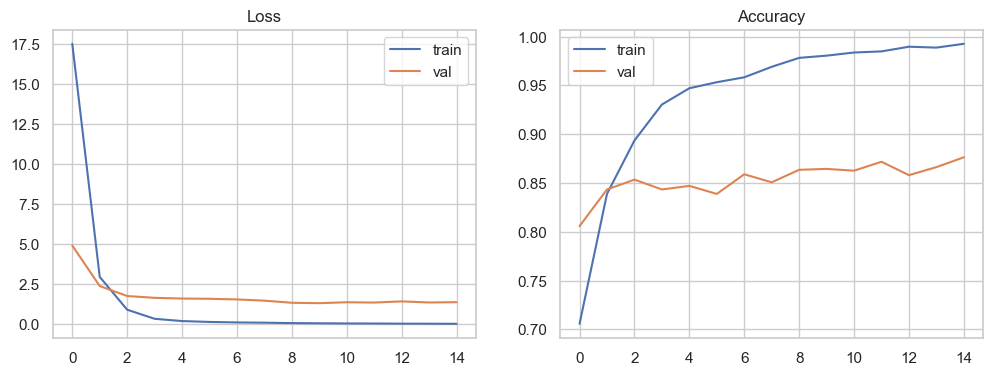

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Accuracy"); axes[1].legend()
plt.show()